In [22]:
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

import numpy as np
import matplotlib.pyplot as plt

In [23]:
import pandas as pd
dry = pd.read_csv('Dry_Lap_Data.csv')
dry.head()

,Unnamed: 0,LapTime,LapNumber,Stint,SpeedI1,SpeedI2,SpeedFL,SpeedST,Compound,TyreLife,...,AirTemp,Humidity,Pressure,Rainfall,TrackTemp,WindDirection,WindSpeed,RoundYear,Rank,TrackRound
0,0,96.296,2,1,232.0,248.0,276.0,287.0,1,5,...,18.3,49.0,1017.0,NaN,23.8,33,1.1,2024_1,1.0,1
1,1,96.862,2,1,NaN,240.0,277.0,293.0,1,5,...,18.3,49.0,1017.1,NaN,23.8,89,1.5,2024_1,2.0,1
2,2,96.635,2,1,230.0,253.0,283.0,298.0,1,5,...,18.3,49.0,1017.1,NaN,23.8,89,1.5,2024_1,4.0,1
3,3,96.541,2,1,234.0,257.0,285.0,302.0,1,5,...,18.3,49.0,1017.1,NaN,23.8,89,1.5,2024_1,1.0,1
4,4,97.236,2,1,235.0,244.0,279.0,297.0,1,5,...,18.3,49.0,1017.1,NaN,23.8,89,1.5,2024_1,2.0,1


random forrest

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

dry = pd.read_csv('Dry_Lap_Data.csv')

df = pd.DataFrame(dry)

X,y = df.drop('LapTime', axis=1), df['LapTime']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, shuffle=False)

In [2]:
#bootstrap smaples
n_samples = len(X_train)
n_bootstraps = 100
all_bootstrap_indices = []
all_oob_indices = []

np.random.seed(42)
for _ in range(n_bootstraps):
    bootstrap_indices = np.random.choice(n_samples, size=n_samples, replace=True)
    oob_indices = list(set(range(n_samples)) - set(bootstrap_indices)) 
    all_bootstrap_indices.append(bootstrap_indices)
    all_oob_indices.append(oob_indices)

samples_to_show = [0,5,27]
for i in samples_to_show:
    print(f"Bootstraping Sample {i}:")
    print("Chosen Indices:", all_bootstrap_indices[i])
    print("OOB Indices:", all_oob_indices[i])  

Bootstraping Sample 0:
Chosen Indices: [15795   860  5390 ... 10909 12713 12614]
OOB Indices: [0, 3, 4, 6, 7, 8, 17, 23, 29, 30, 33, 34, 35, 43, 46, 49, 52, 54, 61, 63, 69, 70, 75, 83, 85, 88, 90, 91, 92, 96, 98, 99, 100, 101, 103, 109, 110, 115, 116, 119, 121, 124, 127, 128, 130, 133, 134, 137, 139, 140, 142, 144, 146, 147, 150, 167, 168, 170, 173, 176, 177, 180, 181, 182, 188, 194, 196, 199, 200, 208, 210, 214, 216, 217, 219, 221, 222, 224, 227, 230, 231, 239, 241, 242, 243, 247, 248, 250, 251, 252, 254, 257, 259, 261, 263, 264, 265, 266, 267, 268, 273, 274, 278, 279, 280, 283, 284, 286, 288, 289, 290, 291, 292, 299, 304, 308, 311, 312, 313, 315, 316, 321, 322, 323, 326, 327, 330, 333, 334, 341, 343, 344, 345, 346, 348, 349, 351, 353, 357, 359, 361, 367, 369, 373, 376, 377, 379, 380, 382, 383, 385, 387, 388, 396, 397, 399, 401, 407, 408, 409, 411, 416, 418, 423, 428, 429, 430, 431, 435, 438, 447, 450, 451, 454, 456, 457, 459, 460, 461, 462, 464, 465, 466, 469, 470, 471, 474, 476, 478

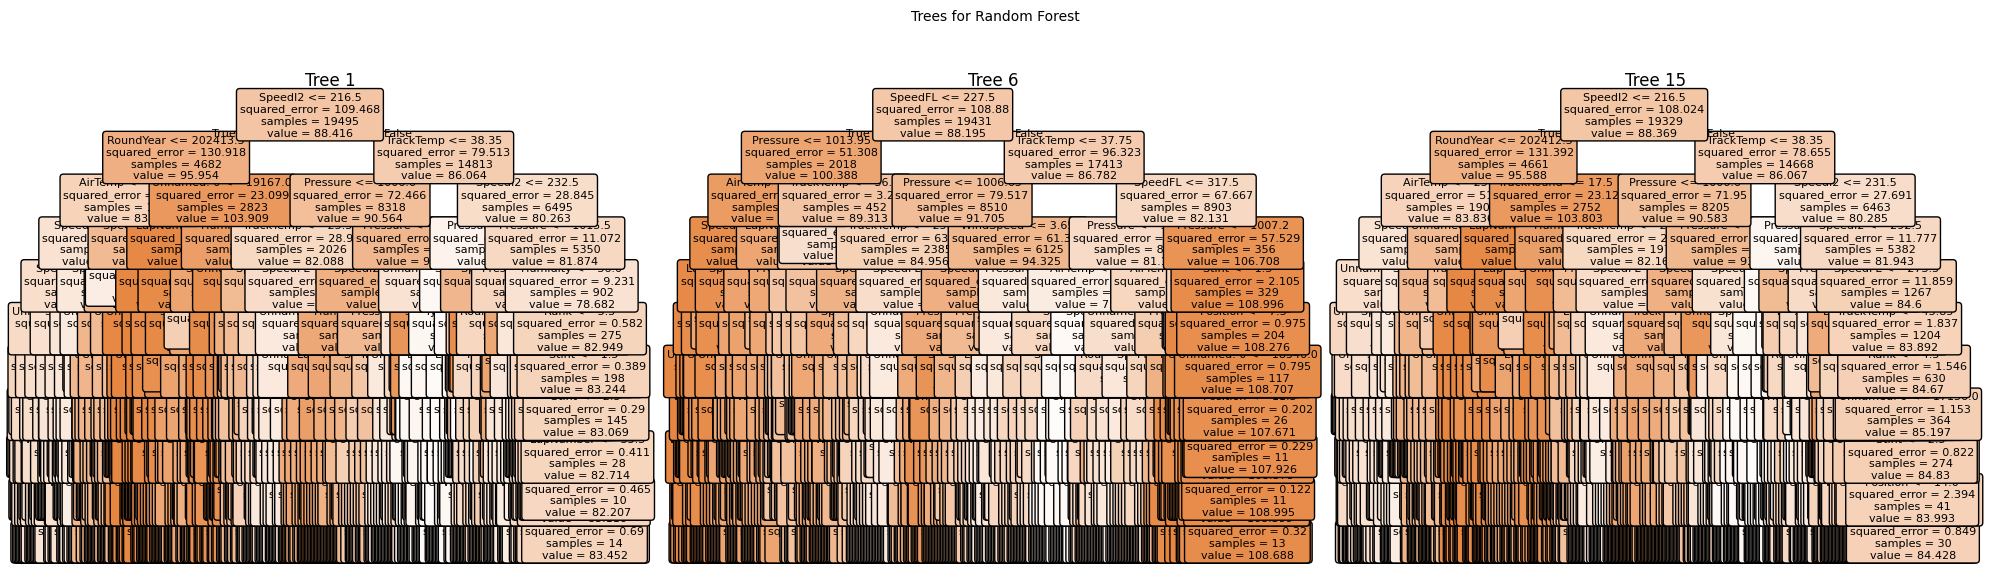

In [ ]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
from sklearn.ensemble import RandomForestRegressor 

# Training Random Forest
np.random.seed(42)  
rf = RandomForestRegressor(n_estimators=100, max_depth = 10, min_samples_leaf = 10,random_state=42)
rf.fit(X_train, y_train)

trees_to_show = [0, 5, 14]
feature_names = X_train.columns.tolist()

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle("Trees for Random Forest", fontsize=10)

for idx, tree_idx in enumerate(trees_to_show):
    plot_tree(rf.estimators_[tree_idx], 
              feature_names=feature_names,
              filled=True,
              rounded=True,
              ax=axes[idx],
              fontsize=8)  
    axes[idx].set_title(f'Tree {tree_idx + 1}', fontsize=12)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])

In [ ]:
from sklearn.metrics import mean_absolute_error, r2_score

y_train_pred = rf.predict(X_train)
y_test_pred = rf.predict(X_test)

print("Result of Random Forest:")
print("Train MeanAS:", mean_absolute_error(y_train, y_train_pred))
print("Test MeanAS:", mean_absolute_error(y_test, y_test_pred))
print("Train RSq:", r2_score(y_train, y_train_pred))
print("Test RSq:", r2_score(y_test, y_test_pred))

Random Forest Result:
Train MAE: 0.4701369375673119
Test MAE: 0.5155609294822001
Train R²: 0.9952946374059755
Test R²: 0.993661525729057


In [ ]:
# predicting lap times for 20laps
print("Actual Times :", y_test[:20].values)
print("Model Predicted Time  :", rf.predict(X_test[:20]))

Actual Times : [ 95.012  98.307  98.182  72.726  84.228  70.618  86.646  81.457 102.252
  78.09   81.745  79.294  81.865  98.196 109.699  98.344 104.759  84.275
  83.498  70.562]
Model Predicted Time  : [ 95.64396297  98.89658817  98.87781897  72.73827365  82.73486068
  71.06533084  85.9202144   81.90034119 102.04181954  79.12000339
  82.56920142  80.48341131  82.396344    97.86143152 109.75033107
  98.74077867 104.80102418  81.98239163  83.62082056  70.94019698]
